In [1]:
! pip install point-cloud-utils
! cd .. && cd .. && cd meshmash && pip install .

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\bkrou\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Processing c:\users\bkrou\spinedetect\meshmash
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for meshmash: filename=meshmash-0.1.0-py3-none-any.whl size=33261 sha256=17eb811ac0d879bb90fd61b3a60c4157ae30ad976bac98eec9182667146b0a25
  Stored in directory: C:\Users\bkrou\AppData\Local\Temp\pip-ephem-wheel-cache-eittdy6o\wheels\4f\2a\a6\bd527fea67811481c23d79b08e3a5ee7db9e7d40519a26019e
Successfully built meshmash
  Attempting uninstall: meshmash
    Found existing installation: meshmash 0.1.0
    Uninstalling meshmash-0.1.0:
      Successfully uninstalled meshmash-0.1.0



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\bkrou\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from caveclient import CAVEclient
from meshparty import trimesh_io, trimesh_vtk

from meshmash import condensed_hks_pipeline

In [4]:
dataset_name = 'minnie65_public'
materialization = 1300      # Required for mesh downloading

client = CAVEclient(dataset_name)
client.info.get_datastack_info()['description']
client.version = materialization

mm =  trimesh_io.MeshMeta(
    cv_path=client.info.segmentation_source(),
    disk_cache_path='meshes'
)

In [5]:
cell_id = 864691134966495519

print(f'Cell ID: { cell_id }')

mesh = mm.mesh(seg_id=cell_id)
mesh.add_link_edges(seg_id=cell_id, client=client.chunkedgraph)

Cell ID: 864691134966495519


SSLError: None: Max retries exceeded with url: /minnie65_pcg/ws/graphene_meshes_minnie3_v1/initial/6/66112-0.shard (Caused by SSLError(SSLEOFError(8, '[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1010)')))

In [5]:
if False:
    mesh_actor = trimesh_vtk.mesh_actor(
        mesh,
        color=(1,0,0),
        opacity=0.5
    )
    trimesh_vtk.render_actors([mesh_actor])

In [6]:
hks = condensed_hks_pipeline(
    (mesh.vertices.astype(np.float32), mesh.faces),
    # simplify_agg=1,
    # simplify_target_reduction=0.1,
    verbose=True
)
hks

Subdividing mesh...
Meshes in queue: 13
Meshes in queue: 6
Finding overlapping submeshes...
Computing HKS across submeshes...


Applying function compute_condensed_hks: 100%|██████████| 70/70 [01:03<00:00,  1.11it/s]


CondensedHKSResult(simple_mesh=(array([[ 579625.2 ,  391634.06,  774284.94],
       [ 579643.9 ,  391646.78,  774531.1 ],
       [ 579642.  ,  391755.  ,  774249.  ],
       ...,
       [1100663.4 ,  655353.44,  594082.56],
       [1100716.6 ,  655481.06,  594055.06],
       [1100686.1 ,  655606.9 ,  594006.  ]],
      shape=(865662, 3), dtype=float32), array([[ 63280,  63375,  63425],
       [ 63425,  63375,  63326],
       [ 63375,  63281,  63326],
       ...,
       [774353, 774572, 774285],
       [774572, 774626, 774285],
       [774353, 774285, 773978]], shape=(1732144, 3))), mapping=array([     0,      0,      0, ..., 865660, 865661, 865661],
      shape=(2896017,), dtype=int32), stitcher=<meshmash.split.MeshStitcher object at 0x00000237EB9FA960>, simple_labels=array([ 3782,  3782,  3782, ..., 15166, 15166, 15166], shape=(865662,)), labels=array([ 3782,  3782,  3782, ..., 15166, 15166, 15166], shape=(2896017,)), condensed_features=            hks_0      hks_1      hks_2      hks

In [7]:
hks.condensed_features

,hks_0,hks_1,hks_2,hks_3,hks_4,hks_5,hks_6,hks_7,hks_8,hks_9,...,hks_22,hks_23,hks_24,hks_25,hks_26,hks_27,hks_28,hks_29,hks_30,hks_31
-1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
0,-14.657326,-14.678188,-14.703169,-14.732994,-14.768473,-14.810488,-14.859967,-14.917836,-14.984939,-15.061925,...,-16.477858,-16.585121,-16.695059,-16.807886,-16.923317,-17.040565,-17.158449,-17.275677,-17.391336,-17.505386
1,-13.598495,-13.632637,-13.673699,-13.722976,-13.781937,-13.852221,-13.935580,-14.033781,-14.148401,-14.280494,...,-16.171167,-16.339207,-16.520618,-16.708973,-16.894499,-17.065861,-17.214027,-17.336416,-17.437805,-17.526999
2,-14.870493,-14.887611,-14.908074,-14.932456,-14.961396,-14.995584,-15.035739,-15.082581,-15.136768,-15.198842,...,-16.550213,-16.668570,-16.784193,-16.896290,-17.004763,-17.110350,-17.214437,-17.318548,-17.423782,-17.530542
3,-14.946928,-14.965646,-14.988107,-15.014997,-15.047100,-15.085295,-15.130552,-15.183915,-15.246468,-15.319279,...,-17.096718,-17.243914,-17.393574,-17.548357,-17.709925,-17.879021,-18.055857,-18.240618,-18.433908,-18.636759
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29487,-13.702353,-13.721169,-13.743812,-13.771016,-13.803636,-13.842655,-13.889196,-13.944525,-14.010039,-14.087264,...,-17.103096,-17.600592,-18.123474,-18.633146,-19.089653,-19.484480,-19.851221,-20.238901,-20.687611,-21.225918
29488,-13.849402,-13.889162,-13.936979,-13.994352,-14.062982,-14.144742,-14.241612,-14.355515,-14.488027,-14.639874,...,-16.277140,-16.397762,-16.541033,-16.712341,-16.918348,-17.167107,-17.468260,-17.833328,-18.276127,-18.813305
29489,-14.009901,-14.024054,-14.040642,-14.059945,-14.082216,-14.107649,-14.136352,-14.168309,-14.203372,-14.241258,...,-15.113023,-15.243480,-15.393542,-15.569056,-15.777355,-16.027197,-16.328783,-16.693995,-17.136827,-17.674013
29490,-14.262048,-14.280300,-14.302094,-14.328025,-14.358753,-14.394985,-14.437454,-14.486885,-14.543948,-14.609207,...,-16.285761,-16.463907,-16.646704,-16.841822,-17.060253,-17.314573,-17.617830,-17.983557,-18.426517,-18.963728


<Axes: >

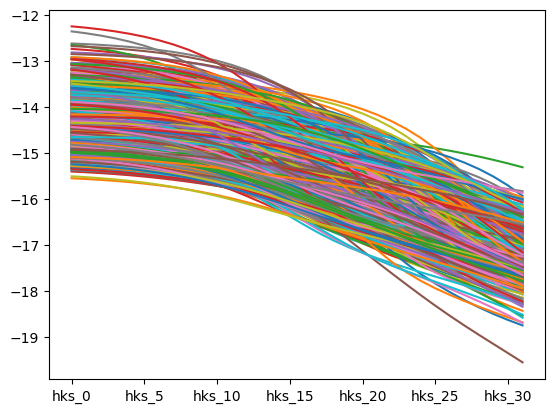

In [8]:
hks.condensed_features.T.iloc[:,::50].plot(legend=False)

In [9]:
from sklearn.cluster import KMeans

values = hks.condensed_features.iloc[1:,:].values
kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(values)

In [10]:
np.unique(kmeans.labels_, return_counts=True)

(array([0, 1, 2, 3], dtype=int32), array([8934, 9386, 4599, 6573]))

<Axes: >

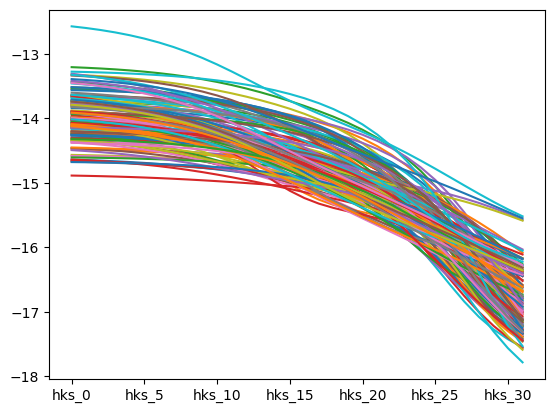

In [11]:
hks.condensed_features.iloc[1:, :][kmeans.labels_ == 3].T.iloc[:,::50].plot(legend=False)

<Axes: >

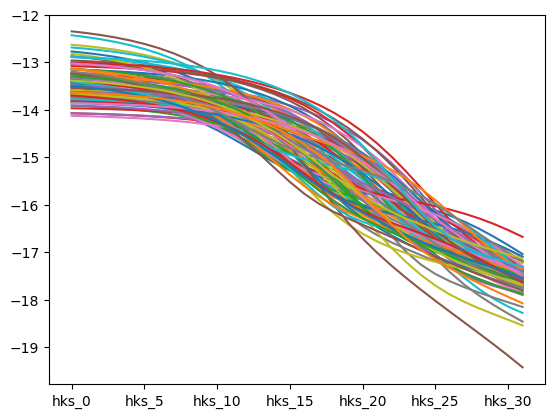

In [12]:
hks.condensed_features.iloc[1:, :][kmeans.labels_ == 2].T.iloc[:,::50].plot(legend=False)

<Axes: >

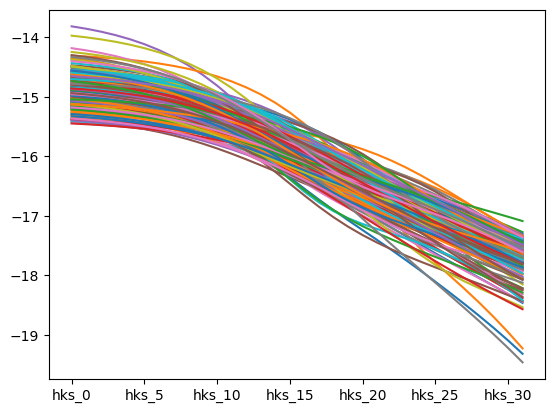

In [13]:
hks.condensed_features.iloc[1:, :][kmeans.labels_ == 1].T.iloc[:,::50].plot(legend=False)

<Axes: >

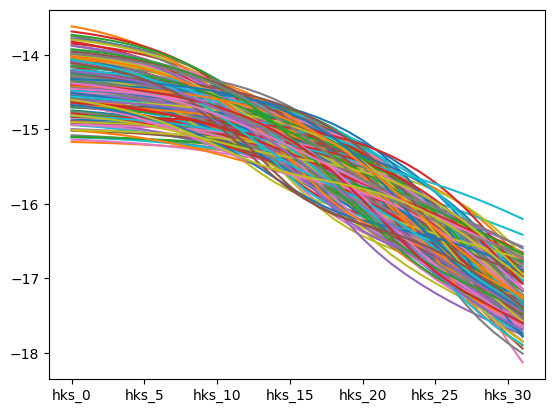

In [14]:
hks.condensed_features.iloc[1:, :][kmeans.labels_ == 0].T.iloc[:,::50].plot(legend=False)

In [15]:
import trimesh

class DKMesh:
    vertices = None
    faces = None


simple_mesh = DKMesh()
simple_mesh.vertices = hks.simple_mesh[0]
simple_mesh.faces = hks.simple_mesh[1]

mesh_actor = trimesh_vtk.mesh_actor(
    simple_mesh,
    color=(1,0,0),
    opacity=0.25
)


trimesh_vtk.render_actors([mesh_actor])

<vtkmodules.vtkRenderingOpenGL2.vtkOpenGLRenderer(0x00000237EDE69BB0) at 0x00000238FC6EFDC0>

In [16]:
import trimesh

mesh_actor = trimesh_vtk.mesh_actor(
    mesh,
    color=(1,0,0),
    opacity=0.25
)

actors = [mesh_actor]

colors = [
    (0, 1, 0),
    (0, 0, 1),
    (0, 1, 1),
    (1, 1, 0)
]

for idx in range(0, len(hks.condensed_features)-10):
    center = hks.condensed_nodes[['x','y','z']].iloc[idx,:].values

    sphere = trimesh.creation.icosphere(radius=50.0)
    sphere.vertices = sphere.vertices + center

    actor = trimesh_vtk.mesh_actor(sphere)
    actor.GetProperty().SetColor(*colors[kmeans.labels_[idx]])
    actor.GetProperty().SetOpacity(1)
    actors.append(actor)

# for idx, label in enumerate(kmeans.labels_):
#     if label != 3: continue

#     center = hks.condensed_nodes[['x','y','z']].iloc[idx,:].values

#     sphere = trimesh.creation.icosphere(radius=500.0)
#     sphere.vertices = sphere.vertices + center

#     actor = trimesh_vtk.mesh_actor(sphere)
#     actor.GetProperty().SetColor(0, 1, 0)
#     actors.append(actor)

print(len(actors))
trimesh_vtk.render_actors(actors)

KeyboardInterrupt: 

In [ ]:
len(hks.condensed_features)

29493

In [ ]:
len(actors)

590